<a href="https://colab.research.google.com/github/Usha-Shatul/DL/blob/main/DL_1st_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded from Google Drive
Dataset Head:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390     

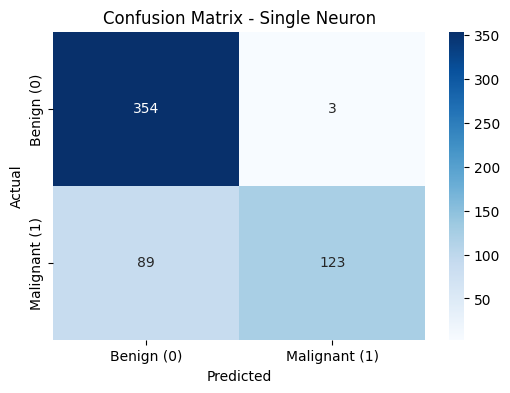


----------------------------------------
NEURAL NETWORK MODEL - Detailed Results
----------------------------------------

--- Neural Network ---
Accuracy: 0.9930
Precision: 1.0000
Recall: 0.9811
F1-Score: 0.9905
Confusion Matrix:
[[357   0]
 [  4 208]]

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.99      1.00      0.99       357
Malignant (1)       1.00      0.98      0.99       212

     accuracy                           0.99       569
    macro avg       0.99      0.99      0.99       569
 weighted avg       0.99      0.99      0.99       569



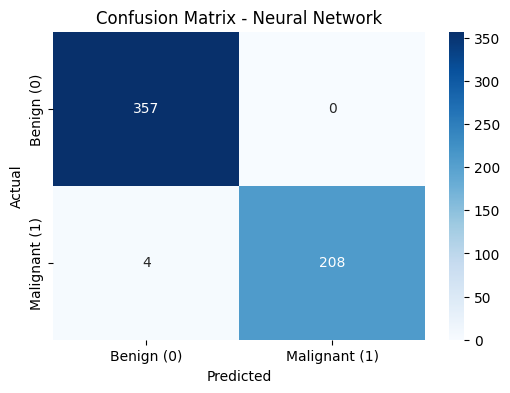


SECTION 4: MODEL COMPARISON
   Metric Single Neuron Neural Network
 Accuracy        0.8383         0.9930
Precision        0.9762         1.0000
   Recall        0.5802         0.9811
 F1-Score        0.7278         0.9905

SECTION 5: EPOCH-WISE ACCURACY COMPARISON

Accuracy at every 20th epoch:
 Epoch  Single Neuron Accuracy  Neural Network Accuracy
     0                0.838313                 0.667838
    20                0.838313                 0.989455
    40                0.838313                 0.989455
    60                0.838313                 0.991213
    80                0.838313                 0.991213
   100                0.838313                 0.991213
   120                0.838313                 0.991213
   140                0.838313                 0.992970
   160                0.838313                 0.992970
   180                0.838313                 0.992970


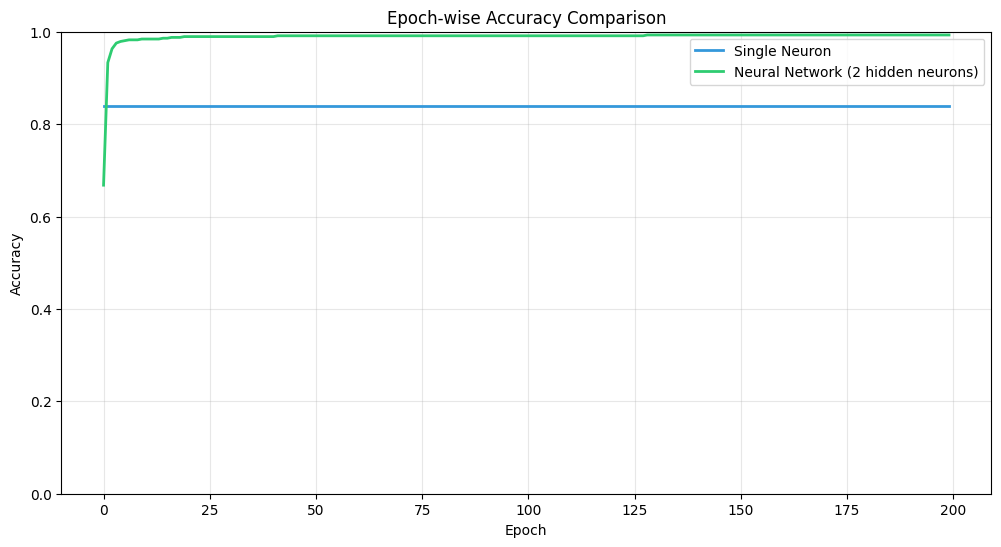


SECTION 6: SAMPLE PREDICTIONS

Predictions for first 10 samples:
Index | Actual | Single Neuron | Neural Network | Correct?
----------------------------------------------------------------------
    0 |   1    |      1       |       1        |     ✓/✓
    1 |   1    |      1       |       1        |     ✓/✓
    2 |   1    |      1       |       1        |     ✓/✓
    3 |   1    |      0       |       1        |     ✗/✓
    4 |   1    |      1       |       1        |     ✓/✓
    5 |   1    |      0       |       1        |     ✗/✓
    6 |   1    |      1       |       1        |     ✓/✓
    7 |   1    |      0       |       1        |     ✗/✓
    8 |   1    |      0       |       1        |     ✗/✓
    9 |   1    |      0       |       1        |     ✗/✓

SECTION 7: ACCURACY COMPARISON VISUALIZATION


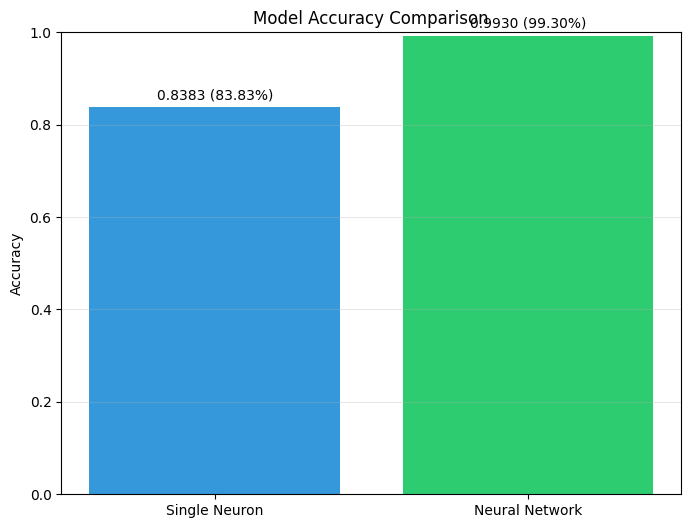


SECTION 8: ADDITIONAL ANALYSIS
Single Neuron - Correct Predictions: 477/569 (83.83%)
Neural Network - Correct Predictions: 565/569 (99.30%)

Single Neuron Misclassified indices: [3, 5, 7, 8, 9]... (showing first 5)
Neural Network Misclassified indices: [40, 73, 135, 297]... (showing first 5)

SECTION 9: FINAL SUMMARY

📊 Summary:
• Neural Network outperforms Single Neuron
• Accuracy improvement: 15.47%
• F1-Score improvement: 26.27%

📊 Dataset Statistics:
• Total samples: 569
• Benign (0): 357 (62.74%)
• Malignant (1): 212 (37.26%)

🎯 Performance Summary:
• Single Neuron Model: 83.83% accuracy
• Neural Network Model: 99.30% accuracy

=== ANALYSIS COMPLETE ===


In [ ]:
import pandas as pd
import math
import numpy as np
from google.colab import drive
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# LOAD DATASET
# =========================
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/dataset/Breast Cancer Wisconsin Dataset.csv")
print("Dataset loaded from Google Drive")
print("Dataset Head:")
print(df.head())
print(f"\nDataset Shape: {df.shape}")

# =========================
# CLEAN DATASET
# =========================

# Drop 'id' column if exists
if "id" in df.columns:
    df = df.drop("id", axis=1)

# Drop 'Unnamed: 32' column if exists (contains only NaN)
if "Unnamed: 32" in df.columns:
    df = df.drop("Unnamed: 32", axis=1)

# Convert label: M = 1, B = 0
if "diagnosis" in df.columns and df["diagnosis"].dtype == 'object':
    df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Remove any rows with missing values
df = df.dropna()

print(f"\nDataset after cleaning: {df.shape}")

# =========================
# FEATURES & LABEL
# =========================
X = df.drop("diagnosis", axis=1).values
Y = df["diagnosis"].values

# Check if dataset is empty
if len(X) == 0:
    raise ValueError("Dataset is empty! Please check your data file.")

print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Class distribution: Benign={(Y==0).sum()}, Malignant={(Y==1).sum()}")

# Normalize (VERY IMPORTANT for NN)
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Use only first feature for single neuron
X_single = X[:, 0]

# =====================================================
# SECTION 1: SINGLE NEURON MODEL (x1 only)
# =====================================================

print("\n" + "="*60)
print("SECTION 1: SINGLE NEURON MODEL (Using only first feature)")
print("="*60)

w = 0.2
b = 0.0
lr = 0.01
epochs_single = 200

# Store predictions for each epoch to track accuracy
single_epoch_accuracies = []
single_epoch_predictions = []

for epoch in range(epochs_single):
    total_loss = 0
    epoch_preds = []

    for i in range(len(X_single)):
        y_pred = w * X_single[i] + b

        error = y_pred - Y[i]
        total_loss += error ** 2

        w -= lr * (2 * error * X_single[i])
        b -= lr * (2 * error)

    # Calculate predictions for this epoch
    epoch_preds = []
    for i in range(len(X_single)):
        pred = w * X_single[i] + b
        epoch_preds.append(1 if pred >= 0.5 else 0)

    # Calculate accuracy for this epoch
    epoch_accuracy = accuracy_score(Y, epoch_preds)
    single_epoch_accuracies.append(epoch_accuracy)

    # Store final predictions
    if epoch == epochs_single - 1:
        single_preds = epoch_preds

    # Print accuracy every 20 epochs
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss={total_loss:.4f} | Accuracy={epoch_accuracy:.4f} ({epoch_accuracy*100:.2f}%)")

print(f"\nFinal Single Neuron - W: {w:.4f}, B: {b:.4f}")
print(f"Final Accuracy: {single_epoch_accuracies[-1]:.4f} ({single_epoch_accuracies[-1]*100:.2f}%)")

# =====================================================
# SECTION 2: NEURAL NETWORK MODEL (2 hidden neurons)
# =====================================================

print("\n" + "="*60)
print("SECTION 2: NEURAL NETWORK MODEL (2 Hidden Neurons)")
print("="*60)

# input size = number of features
input_size = X.shape[1]

# Initialize weights with small random values
np.random.seed(42)
W1 = np.random.randn(2, input_size) * 0.01
b1 = np.zeros(2)
W2 = np.random.randn(2) * 0.01
b2 = 0.0

lr = 0.1
epochs_nn = 200

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    return sigmoid(z) * (1 - sigmoid(z))

# Store predictions for each epoch to track accuracy
nn_epoch_accuracies = []
nn_epoch_predictions = []

for epoch in range(epochs_nn):
    total_loss = 0
    epoch_preds = []

    for i in range(len(X)):
        # =========================
        # Forward pass
        # =========================
        # Hidden layer
        z1 = np.dot(W1, X[i]) + b1
        h = sigmoid(z1)

        # Output layer
        z2 = np.dot(W2, h) + b2
        y_pred = sigmoid(z2)

        # Store prediction
        epoch_preds.append(1 if y_pred >= 0.5 else 0)

        # =========================
        # Backpropagation
        # =========================
        error = y_pred - Y[i]
        total_loss += error ** 2

        # Output layer gradient
        d_output = error * sigmoid_derivative(z2)

        # Hidden layer gradient
        d_hidden = d_output * W2 * sigmoid_derivative(z1)

        # Update weights and biases
        W2 -= lr * d_output * h
        b2 -= lr * d_output

        W1 -= lr * np.outer(d_hidden, X[i])
        b1 -= lr * d_hidden

    # Calculate accuracy for this epoch
    epoch_accuracy = accuracy_score(Y, epoch_preds)
    nn_epoch_accuracies.append(epoch_accuracy)

    # Store final predictions
    if epoch == epochs_nn - 1:
        nn_preds = epoch_preds

    # Print accuracy every 20 epochs
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss={total_loss:.4f} | Accuracy={epoch_accuracy:.4f} ({epoch_accuracy*100:.2f}%)")

print(f"\nFinal Neural Network - W2: {W2}")
print(f"Final Accuracy: {nn_epoch_accuracies[-1]:.4f} ({nn_epoch_accuracies[-1]*100:.2f}%)")

# =====================================================
# SECTION 3: MODEL EVALUATION
# =====================================================

print("\n" + "="*60)
print("SECTION 3: MODEL EVALUATION")
print("="*60)

# Function to calculate metrics
def calculate_metrics(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")

    # Check if predictions are valid
    if len(y_pred) == 0 or len(np.unique(y_pred)) == 0:
        print("Warning: No predictions available!")
        return {
            'accuracy': 0,
            'precision': 0,
            'recall': 0,
            'f1': 0,
            'confusion_matrix': np.array([[0, 0], [0, 0]])
        }

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    # Precision
    try:
        precision = precision_score(y_true, y_pred, zero_division=0)
        print(f"Precision: {precision:.4f}")
    except:
        precision = 0
        print(f"Precision: 0.0000")

    # Recall
    try:
        recall = recall_score(y_true, y_pred, zero_division=0)
        print(f"Recall: {recall:.4f}")
    except:
        recall = 0
        print(f"Recall: 0.0000")

    # F1-Score
    try:
        f1 = f1_score(y_true, y_pred, zero_division=0)
        print(f"F1-Score: {f1:.4f}")
    except:
        f1 = 0
        print(f"F1-Score: 0.0000")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"Confusion Matrix:")
    print(cm)

    # Classification Report
    from sklearn.metrics import classification_report
    try:
        print(f"\nClassification Report:")
        print(classification_report(y_true, y_pred, target_names=['Benign (0)', 'Malignant (1)'], zero_division=0))
    except Exception as e:
        print(f"Classification Report: Error - {e}")

    # Confusion Matrix Visualization
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign (0)', 'Malignant (1)'],
                yticklabels=['Benign (0)', 'Malignant (1)'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }

# Calculate metrics for Single Neuron
print("\n" + "-"*40)
print("SINGLE NEURON MODEL - Detailed Results")
print("-"*40)
single_metrics = calculate_metrics(Y, single_preds, "Single Neuron")

# Calculate metrics for Neural Network
print("\n" + "-"*40)
print("NEURAL NETWORK MODEL - Detailed Results")
print("-"*40)
nn_metrics = calculate_metrics(Y, nn_preds, "Neural Network")

# =====================================================
# SECTION 4: MODEL COMPARISON
# =====================================================

print("\n" + "="*60)
print("SECTION 4: MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Single Neuron': [
        f"{single_metrics['accuracy']:.4f}",
        f"{single_metrics['precision']:.4f}",
        f"{single_metrics['recall']:.4f}",
        f"{single_metrics['f1']:.4f}"
    ],
    'Neural Network': [
        f"{nn_metrics['accuracy']:.4f}",
        f"{nn_metrics['precision']:.4f}",
        f"{nn_metrics['recall']:.4f}",
        f"{nn_metrics['f1']:.4f}"
    ]
})

print(comparison_df.to_string(index=False))

# =====================================================
# SECTION 5: EPOCH-WISE ACCURACY COMPARISON
# =====================================================

print("\n" + "="*60)
print("SECTION 5: EPOCH-WISE ACCURACY COMPARISON")
print("="*60)

# Create a comparison table for epoch-wise accuracy
epoch_comparison = pd.DataFrame({
    'Epoch': range(0, epochs_single, 20),
    'Single Neuron Accuracy': [single_epoch_accuracies[i] for i in range(0, epochs_single, 20)],
    'Neural Network Accuracy': [nn_epoch_accuracies[i] for i in range(0, epochs_nn, 20)]
})

print("\nAccuracy at every 20th epoch:")
print(epoch_comparison.to_string(index=False))

# Plot epoch-wise accuracy comparison
plt.figure(figsize=(12, 6))
plt.plot(range(epochs_single), single_epoch_accuracies, label='Single Neuron', color='#3498db', linewidth=2)
plt.plot(range(epochs_nn), nn_epoch_accuracies, label='Neural Network (2 hidden neurons)', color='#2ecc71', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Epoch-wise Accuracy Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.0)
plt.show()

# =====================================================
# SECTION 6: SAMPLE PREDICTIONS
# =====================================================

print("\n" + "="*60)
print("SECTION 6: SAMPLE PREDICTIONS")
print("="*60)

num_samples = min(10, len(X))
print(f"\nPredictions for first {num_samples} samples:")
print("Index | Actual | Single Neuron | Neural Network | Correct?")
print("-"*70)

for i in range(num_samples):
    correct_single = "✓" if single_preds[i] == Y[i] else "✗"
    correct_nn = "✓" if nn_preds[i] == Y[i] else "✗"
    print(f"{i:5d} |   {Y[i]:d}    |      {single_preds[i]:d}       |       {nn_preds[i]:d}        |     {correct_single}/{correct_nn}")

# =====================================================
# SECTION 7: ACCURACY COMPARISON BAR CHART
# =====================================================

print("\n" + "="*60)
print("SECTION 7: ACCURACY COMPARISON VISUALIZATION")
print("="*60)

models = ['Single Neuron', 'Neural Network']
accuracies = [single_metrics['accuracy'], nn_metrics['accuracy']]

plt.figure(figsize=(8, 6))
bars = plt.bar(models, accuracies, color=['#3498db', '#2ecc71'])
plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f} ({acc*100:.2f}%)', ha='center', va='bottom')

plt.show()

# =====================================================
# SECTION 8: ADDITIONAL ANALYSIS
# =====================================================

print("\n" + "="*60)
print("SECTION 8: ADDITIONAL ANALYSIS")
print("="*60)

# Calculate how many samples each model got right
single_correct = sum(1 for i in range(len(Y)) if single_preds[i] == Y[i])
nn_correct = sum(1 for i in range(len(Y)) if nn_preds[i] == Y[i])

print(f"Single Neuron - Correct Predictions: {single_correct}/{len(Y)} ({single_correct/len(Y)*100:.2f}%)")
print(f"Neural Network - Correct Predictions: {nn_correct}/{len(Y)} ({nn_correct/len(Y)*100:.2f}%)")

# Error analysis
single_errors = [i for i in range(len(Y)) if single_preds[i] != Y[i]]
nn_errors = [i for i in range(len(Y)) if nn_preds[i] != Y[i]]

if single_errors:
    print(f"\nSingle Neuron Misclassified indices: {single_errors[:5]}... (showing first 5)")
if nn_errors:
    print(f"Neural Network Misclassified indices: {nn_errors[:5]}... (showing first 5)")

# =====================================================
# SECTION 9: FINAL SUMMARY
# =====================================================

print("\n" + "="*60)
print("SECTION 9: FINAL SUMMARY")
print("="*60)

# Summary
print("\n📊 Summary:")
if nn_metrics['accuracy'] > single_metrics['accuracy']:
    print(f"• Neural Network outperforms Single Neuron")
    print(f"• Accuracy improvement: {(nn_metrics['accuracy'] - single_metrics['accuracy'])*100:.2f}%")
    print(f"• F1-Score improvement: {(nn_metrics['f1'] - single_metrics['f1'])*100:.2f}%")
else:
    print(f"• Single Neuron outperforms Neural Network")
    print(f"• Accuracy difference: {(single_metrics['accuracy'] - nn_metrics['accuracy'])*100:.2f}%")
    print(f"• F1-Score difference: {(single_metrics['f1'] - nn_metrics['f1'])*100:.2f}%")

# Dataset statistics
print(f"\n📊 Dataset Statistics:")
print(f"• Total samples: {len(Y)}")
print(f"• Benign (0): {(Y==0).sum()} ({(Y==0).sum()/len(Y)*100:.2f}%)")
print(f"• Malignant (1): {(Y==1).sum()} ({(Y==1).sum()/len(Y)*100:.2f}%)")

# Performance summary
print(f"\n🎯 Performance Summary:")
print(f"• Single Neuron Model: {single_metrics['accuracy']*100:.2f}% accuracy")
print(f"• Neural Network Model: {nn_metrics['accuracy']*100:.2f}% accuracy")

print("\n" + "="*60)
print("=== ANALYSIS COMPLETE ===")
print("="*60)